# 05 — Predict 2026 World Cup Matches

Train the final hybrid (DC-into-XGBoost + squad value) on all played matches, then predict the upcoming 2026 fixtures.

In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import poisson
import xgboost as xgb

## Load played matches + upcoming fixtures

In [2]:
played = pd.read_parquet("../data/processed/results_clean.parquet")
played["neutral"] = (played["neutral"].astype(str).str.upper()
                     .map({"TRUE":True,"FALSE":False}).fillna(False).astype(bool))

raw = pd.read_csv("../data/raw/international_results/results.csv")
raw["date"] = pd.to_datetime(raw["date"])
future = raw[raw["home_score"].isna()].copy()
future["neutral"] = (future["neutral"].astype(str).str.upper()
                     .map({"TRUE":True,"FALSE":False}).fillna(False).astype(bool))
keep = ["date","home_team","away_team","home_score","away_score","tournament","city","country","neutral"]
combined = pd.concat([played[keep], future[keep]], ignore_index=True)
combined = combined.sort_values(["date","home_team","away_team"], kind="mergesort").reset_index(drop=True)
print(f"played={len(played)}  upcoming fixtures={len(future)}  ({future['date'].min().date()} -> {future['date'].max().date()})")
print("upcoming teams known in played set:",
      future['home_team'].isin(played['home_team']).all() and future['away_team'].isin(played['away_team']).all())

played=19005  upcoming fixtures=28  (2026-06-23 -> 2026-06-27)
upcoming teams known in played set: True


## Model code

Dixon-Coles fit, competitiveness ordinal, and squad-value lookup.

In [3]:
def fit_dc(df_train, xi=0.0005, maxiter=400):
    df_train = df_train[df_train["home_score"].notna()]
    teams = sorted(set(df_train["home_team"]) | set(df_train["away_team"]))
    idx = {t:i for i,t in enumerate(teams)}; n=len(teams)
    hi=df_train["home_team"].map(idx).to_numpy(np.int64); ai=df_train["away_team"].map(idx).to_numpy(np.int64)
    hg=df_train["home_score"].to_numpy(np.int64); ag=df_train["away_score"].to_numpy(np.int64)
    days=(df_train["date"].max()-df_train["date"]).dt.days.to_numpy(float); w=np.exp(-xi*days)
    m00=(hg==0)&(ag==0);m01=(hg==0)&(ag==1);m10=(hg==1)&(ag==0);m11=(hg==1)&(ag==1)
    def unpack(p):
        att=np.concatenate([p[:n-1],[-p[:n-1].sum()]]); return att,p[n-1:2*n-1],p[2*n-1],p[2*n]
    def tau(lam,mu,rho):
        t=np.ones_like(lam); t[m00]=1-lam[m00]*mu[m00]*rho; t[m01]=1+lam[m01]*rho; t[m10]=1+mu[m10]*rho; t[m11]=1-rho
        return np.clip(t,1e-10,None)
    def nll(p):
        att,dfn,ha,rho=unpack(p); ll=np.clip(ha+att[hi]+dfn[ai],-10,10); lm=np.clip(att[ai]+dfn[hi],-10,10)
        lam,mu=np.exp(ll),np.exp(lm); return -np.sum(w*(hg*ll-lam+ag*lm-mu+np.log(tau(lam,mu,rho))))
    def grad(p):
        att,dfn,ha,rho=unpack(p); lam=np.exp(np.clip(ha+att[hi]+dfn[ai],-10,10)); mu=np.exp(np.clip(att[ai]+dfn[hi],-10,10))
        t=tau(lam,mu,rho); dl=np.zeros_like(lam);dm=np.zeros_like(lam);dr=np.zeros_like(lam)
        dl[m00]=-mu[m00]*rho;dm[m00]=-lam[m00]*rho;dr[m00]=-lam[m00]*mu[m00]
        dl[m01]=rho;dr[m01]=lam[m01];dm[m10]=rho;dr[m10]=mu[m10];dr[m11]=-1.0
        Sl=w*(hg-lam+(lam/t)*dl);Sm=w*(ag-mu+(mu/t)*dm);Sr=w*(dr/t)
        ga=-(np.bincount(hi,Sl,n)+np.bincount(ai,Sm,n)); gd=-(np.bincount(ai,Sl,n)+np.bincount(hi,Sm,n))
        return np.concatenate([ga[:n-1]-ga[n-1],gd,[-Sl.sum()],[-Sr.sum()]])
    x0=np.concatenate([np.zeros(n-1),np.zeros(n),[0.25],[0.0]]); bounds=[(None,None)]*(2*n-1)+[(None,None),(-0.1,0.1)]
    r=minimize(nll,x0,jac=grad,method="L-BFGS-B",bounds=bounds,options={"maxiter":maxiter}); att,dfn,ha,rho=unpack(r.x)
    return {"idx":idx,"att":att,"dfn":dfn,"home_adv":float(ha),"rho":float(rho)}

In [4]:
def competitiveness(t):
    tl=t.lower()
    if "friendly" in tl: return 0
    if t=="FIFA World Cup": return 5
    if t in {"UEFA Euro","Copa América","African Cup of Naptions","AFC Asian Cup","Gold Cup"}: return 4
    if "fifa world cup qualification" in tl: return 3
    if "qualification" in tl or "nations league" in tl: return 2
    return 1
SQUAD = pd.read_parquet("../data/processed/squad_value.parquet").sort_values("asof_date")
NAME2TM = {"Bosnia and Herzegovina":"Bosnia-Herzegovina","Curaçao":"Curacao","Ivory Coast":"Cote d'Ivoire",
           "Republic of Ireland":"Ireland","South Korea":"Korea, South","North Korea":"Korea, North"}
squad_map = {nat:(g["asof_date"].to_numpy(),g["sv_top25"].to_numpy()) for nat,g in SQUAD.groupby("nation")}
def squad_value(team,date):
    e=squad_map.get(NAME2TM.get(team,team))
    if e is None: return np.nan
    dts,vals=e; pos=np.searchsorted(dts,date,side="right")-1
    return vals[pos] if pos>=0 else np.nan

## Feature builder

Unplayed fixtures get pre-match features but don't update the accumulators.

In [5]:
def build_features(df_in, dc_cadence="6MS", dc_min_train=500):
    d=df_in.sort_values(["date","home_team","away_team"],kind="mergesort").reset_index(drop=True); N=len(d)
    dates=d["date"].to_numpy(); home=d["home_team"].to_numpy(); away=d["away_team"].to_numpy()
    hg=d["home_score"].to_numpy(float); ag=d["away_score"].to_numpy(float)
    neutral=d["neutral"].to_numpy(); host=d["country"].to_numpy()

    cuts=pd.date_range(d["date"].min().normalize(),d["date"].max(),freq=dc_cadence); fits={}
    for c in cuts:
        tr=d[(d["date"]<c)&(d["home_score"].notna())]; fits[c]=fit_dc(tr) if len(tr)>=dc_min_train else None
    cut_idx=np.searchsorted(cuts.values,dates,side="right")-1
    att_h=np.full(N,np.nan);dfn_h=np.full(N,np.nan);att_a=np.full(N,np.nan);dfn_a=np.full(N,np.nan)
    dc_lam=np.full(N,np.nan);dc_mu=np.full(N,np.nan);dc_ph=np.full(N,np.nan);dc_pd=np.full(N,np.nan);dc_pa=np.full(N,np.nan)
    gi=np.arange(11)
    for i in range(N):
        ci=cut_idx[i]; m=fits[cuts[ci]] if ci>=0 else None
        if m is None: continue
        ix=m["idx"]
        if home[i] not in ix or away[i] not in ix: continue
        ah,dh=m["att"][ix[home[i]]],m["dfn"][ix[home[i]]]; aa,da=m["att"][ix[away[i]]],m["dfn"][ix[away[i]]]
        adv=0.0 if neutral[i] else m["home_adv"]; rho=m["rho"]; lam=np.exp(adv+ah+da); mu=np.exp(aa+dh)
        att_h[i],dfn_h[i],att_a[i],dfn_a[i]=ah,dh,aa,da; dc_lam[i],dc_mu[i]=lam,mu
        mat=np.outer(poisson.pmf(gi,lam),poisson.pmf(gi,mu))
        mat[0,0]*=1-lam*mu*rho;mat[0,1]*=1+lam*rho;mat[1,0]*=1+mu*rho;mat[1,1]*=1-rho; s=mat.sum()
        if s>0:
            mat/=s; dc_ph[i]=np.tril(mat,-1).sum(); dc_pd[i]=np.trace(mat); dc_pa[i]=np.triu(mat,1).sum()

    K,HFA=20.0,65.0; elo={};hist={};last_played={};h2h={}
    elo_h=np.full(N,np.nan);elo_a=np.full(N,np.nan)
    f5_gf_h=np.full(N,np.nan);f5_ga_h=np.full(N,np.nan);f5_ppg_h=np.full(N,np.nan)
    f5_gf_a=np.full(N,np.nan);f5_ga_a=np.full(N,np.nan);f5_ppg_a=np.full(N,np.nan)
    f10_ppg_h=np.full(N,np.nan);f10_ppg_a=np.full(N,np.nan)
    rest_h=np.full(N,np.nan);rest_a=np.full(N,np.nan)
    h2h_n=np.zeros(N);h2h_gd=np.full(N,np.nan);h2h_winrate=np.full(N,np.nan)
    def form(t,n):
        h=hist.get(t,[])
        if not h: return (np.nan,np.nan,np.nan)
        w=h[-n:]; return (np.mean([x[0] for x in w]),np.mean([x[1] for x in w]),np.mean([x[2] for x in w]))
    for i in range(N):
        H,A=home[i],away[i]
        eh=elo.get(H,1500.0);ea=elo.get(A,1500.0); elo_h[i]=eh;elo_a[i]=ea
        f5_gf_h[i],f5_ga_h[i],f5_ppg_h[i]=form(H,5); f5_gf_a[i],f5_ga_a[i],f5_ppg_a[i]=form(A,5)
        f10_ppg_h[i]=form(H,10)[2]; f10_ppg_a[i]=form(A,10)[2]
        if H in last_played: rest_h[i]=min((dates[i]-last_played[H]).astype("timedelta64[D]").astype(int),7)
        if A in last_played: rest_a[i]=min((dates[i]-last_played[A]).astype("timedelta64[D]").astype(int),7)
        key=frozenset((H,A)); pm=h2h.get(key,[])
        if pm:
            h2h_n[i]=len(pm); gds=[gd if ht==H else -gd for ht,gd in pm]; h2h_gd[i]=np.mean(gds)
            h2h_winrate[i]=np.mean([1.0 if g>0 else (0.5 if g==0 else 0.0) for g in gds])
        if not np.isnan(hg[i]):                       # UPDATE only for played matches
            adv=0.0 if neutral[i] else HFA
            e_home=1.0/(1.0+10**((ea-(eh+adv))/400.0)); s_home=1.0 if hg[i]>ag[i] else (0.5 if hg[i]==ag[i] else 0.0)
            gd=abs(int(hg[i]-ag[i])); g=1.0 if gd<=1 else (1.5 if gd==2 else (11+gd)/8.0)
            delta=K*g*(s_home-e_home); elo[H]=eh+delta; elo[A]=ea-delta
            ph=3 if hg[i]>ag[i] else (1 if hg[i]==ag[i] else 0); pa=3 if ag[i]>hg[i] else (1 if hg[i]==ag[i] else 0)
            hist.setdefault(H,[]).append((hg[i],ag[i],ph)); hist.setdefault(A,[]).append((ag[i],hg[i],pa))
            last_played[H]=dates[i]; last_played[A]=dates[i]; h2h.setdefault(key,[]).append((H,int(hg[i]-ag[i])))

    is_home_h=np.zeros(N);is_home_a=np.zeros(N); sv_h=np.full(N,np.nan);sv_a=np.full(N,np.nan)
    for i in range(N):
        H,A=home[i],away[i]
        is_home_h[i]=0.0 if neutral[i] else float(H==host[i]); is_home_a[i]=0.0 if neutral[i] else float(A==host[i])
        sv_h[i]=squad_value(H,dates[i]); sv_a[i]=squad_value(A,dates[i])
    return pd.DataFrame({
        "date":d["date"],"home_team":home,"away_team":away,"neutral":neutral,"tournament":d["tournament"],
        "att_home":att_h,"dfn_home":dfn_h,"att_away":att_a,"dfn_away":dfn_a,
        "dc_lam":dc_lam,"dc_mu":dc_mu,"dc_ph":dc_ph,"dc_pd":dc_pd,"dc_pa":dc_pa,
        "elo_home":elo_h,"elo_away":elo_a,"elo_diff":elo_h-elo_a,
        "f5_gf_home":f5_gf_h,"f5_ga_home":f5_ga_h,"f5_ppg_home":f5_ppg_h,
        "f5_gf_away":f5_gf_a,"f5_ga_away":f5_ga_a,"f5_ppg_away":f5_ppg_a,
        "f10_ppg_home":f10_ppg_h,"f10_ppg_away":f10_ppg_a,
        "rest_home":rest_h,"rest_away":rest_a,"rest_diff":rest_h-rest_a,
        "is_home_home":is_home_h,"is_home_away":is_home_a,
        "competitiveness":d["tournament"].map(competitiveness).astype(float),
        "h2h_n":h2h_n,"h2h_gd":h2h_gd,"h2h_winrate":h2h_winrate,
        "sv_home":sv_h,"sv_away":sv_a,"sv_diff":sv_h-sv_a,
        "home_score":hg,"away_score":ag})

## Build features and train the final hybrid

Build features for played + upcoming fixtures, then train the two Poisson regressors on the played matches.

In [6]:
%time feat_all = build_features(combined)
feat_all["neutral_int"]=feat_all["neutral"].astype(int)
KEYS={"date","home_team","away_team","tournament","neutral","home_score","away_score"}
FEATURES=[c for c in feat_all.columns if c not in KEYS and c!="neutral_int"]+["neutral_int"]

is_future = feat_all["home_score"].isna()
train = feat_all[~is_future].copy(); fut = feat_all[is_future].copy()
print("train rows:",len(train)," future rows:",len(fut)," features:",len(FEATURES))

def train_poisson(Xtr,ytr,Xval,yval):
    m=xgb.XGBRegressor(objective="count:poisson",max_depth=3,learning_rate=0.05,n_estimators=2000,
        subsample=0.8,colsample_bytree=0.8,min_child_weight=5,reg_lambda=1.0,
        early_stopping_rounds=40,eval_metric="poisson-nloglik",n_jobs=-1,verbosity=0)
    m.fit(Xtr,ytr,eval_set=[(Xval,yval)],verbose=False); return m

cut=train["date"].quantile(0.9); trn,val=train[train.date<=cut],train[train.date>cut]
mh=train_poisson(trn[FEATURES],trn["home_score"],val[FEATURES],val["home_score"])
ma=train_poisson(trn[FEATURES],trn["away_score"],val[FEATURES],val["away_score"])
print("final models trained on", len(train), "played matches")

CPU times: user 8.87 s, sys: 226 ms, total: 9.1 s
Wall time: 9.1 s
train rows: 19005  future rows: 28  features: 33


final models trained on 19005 played matches


## Predict each fixture: expected goals, W/D/L, and markets

In [7]:
gi=np.arange(11)
def matrix(lam,mu):
    lam=max(float(lam),1e-6);mu=max(float(mu),1e-6)
    m=np.outer(poisson.pmf(gi,lam),poisson.pmf(gi,mu)); return m/m.sum()
def markets(lam,mu):
    m=matrix(lam,mu); I,J=np.indices(m.shape)
    top=np.unravel_index(np.argmax(m),m.shape)
    return {"P_home":np.tril(m,-1).sum(),"P_draw":np.trace(m),"P_away":np.triu(m,1).sum(),
            "P_over2.5":m[(I+J)>=3].sum(),"P_btts":m[(I>=1)&(J>=1)].sum(),
            "top_score":f"{top[0]}-{top[1]}"}
lam_f=mh.predict(fut[FEATURES]); mu_f=ma.predict(fut[FEATURES])
rows=[]
for k,(_,r) in enumerate(fut.iterrows()):
    mk=markets(lam_f[k],mu_f[k])
    rows.append({"date":r["date"].date(),"home":r["home_team"],"away":r["away_team"],
                 "xG_home":round(float(lam_f[k]),2),"xG_away":round(float(mu_f[k]),2),
                 "P_home":round(mk["P_home"]*100),"P_draw":round(mk["P_draw"]*100),"P_away":round(mk["P_away"]*100),
                 "top":mk["top_score"],"P_o2.5":round(mk["P_over2.5"]*100),"P_btts":round(mk["P_btts"]*100)})
pred = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
pred

,date,home,away,xG_home,xG_away,P_home,P_draw,P_away,top,P_o2.5,P_btts
0,2026-06-23,Colombia,DR Congo,2.01,0.75,67,20,13,2-0,52,46
1,2026-06-23,England,Ghana,2.29,0.65,75,17,9,2-0,56,43
2,2026-06-23,Panama,Croatia,0.76,2.30,11,17,72,0-2,59,48
3,2026-06-23,Portugal,Uzbekistan,2.43,0.69,76,16,9,2-0,60,46
4,2026-06-24,Bosnia and Herzegovina,Qatar,1.53,0.95,51,26,23,1-0,45,48
5,2026-06-24,Canada,Switzerland,1.02,1.40,27,27,46,1-1,44,48
6,2026-06-24,Mexico,Czech Republic,1.58,0.90,53,25,21,1-0,45,47
7,2026-06-24,Morocco,Haiti,2.46,0.64,77,15,8,2-0,60,43
8,2026-06-24,Scotland,Brazil,0.60,2.13,9,18,73,0-2,51,40
9,2026-06-24,South Africa,South Korea,0.83,1.52,20,26,54,0-1,42,44


## Visualize a game's score matrix

Type `HOME` / `AWAY` (one of the 28 fixtures) to plot that game's scoreline distribution; the most-likely score is outlined in red.

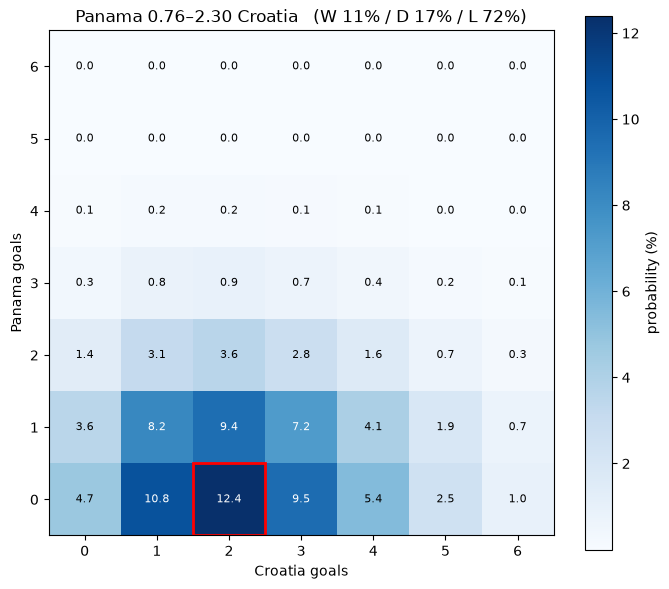

In [35]:
import matplotlib.pyplot as plt

# ── type the matchup here ──
HOME = "Panama"
AWAY = "Croatia"
# ───────────────────────────

mask = ((fut["home_team"] == HOME) & (fut["away_team"] == AWAY)).to_numpy()
if not mask.any():
    raise ValueError(f"No upcoming fixture {HOME} vs {AWAY}.\nAvailable:\n"
                     + fut[["home_team", "away_team"]].to_string(index=False))
k = int(np.flatnonzero(mask)[0])
lam, mu = float(lam_f[k]), float(mu_f[k])
m  = matrix(lam, mu)          # full 11x11 normalized score matrix (existing helper)
mk = markets(lam, mu)

G = 6                         # show 0..6 goals (mass beyond is negligible)
sub = m[:G + 1, :G + 1] * 100
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(sub, cmap="Blues", origin="lower")   # 0-0 in the bottom-left corner
ax.set_xticks(range(G + 1)); ax.set_yticks(range(G + 1))
ax.set_xlabel(f"{AWAY} goals"); ax.set_ylabel(f"{HOME} goals")
ax.set_title(f"{HOME} {lam:.2f}–{mu:.2f} {AWAY}   "
             f"(W {mk['P_home']*100:.0f}% / D {mk['P_draw']*100:.0f}% / "
             f"L {mk['P_away']*100:.0f}%)")
for i in range(G + 1):
    for j in range(G + 1):
        ax.text(j, i, f"{sub[i, j]:.1f}", ha="center", va="center",
                color="white" if sub[i, j] > sub.max() * 0.5 else "black", fontsize=8)
ti, tj = np.unravel_index(np.argmax(m), m.shape)   # most-likely scoreline
if ti <= G and tj <= G:
    ax.add_patch(plt.Rectangle((tj - 0.5, ti - 0.5), 1, 1,
                               fill=False, edgecolor="red", lw=2))
fig.colorbar(im, ax=ax, label="probability (%)")
plt.tight_layout(); plt.show()

## Save predictions

In [9]:
pred.to_csv("../data/processed/predictions_2026.csv", index=False)
print("wrote ../data/processed/predictions_2026.csv", pred.shape)

wrote ../data/processed/predictions_2026.csv (28, 11)
